# Chapter E. Spatio-temporal Processes

## Learning Objectives

After completing this chapter, you should be able to:
1. Construct lagged environmental predicates on a common eligible anchor-period population.
2. Simulate binary Markov environmental fields and interpret persistence（持续性）.
3. Distinguish lag-specific marginal association from identification of a causal delay.
4. Demonstrate seasonal target variation and why naive row permutations can fail.
5. Compute an empirical lag-profile for a known planted lag-2 mechanism.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

Many phenomena are dynamic: past conditions predict or accompany later events, seasons repeat, shocks propagate, and neighboring regions interact. **Spatio-temporal statistics (时空统计学)** extends spatial and time-series reasoning to observations indexed by both location and time. It is used for infectious-disease spread, air pollution, flood risk, urban mobility, and climate extremes.

**Questions it answers:** What persists through time? How do we distinguish a true delayed influence from autocorrelation? What is the difference between trend, seasonality and lagged association? How should we compare time offsets fairly?

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### Temporal dependence is more than a lag
For a weakly stationary process $X_t$, $\gamma(h)=\mathrm{Cov}(X_t,X_{t-h})$ and $\rho(h)=\gamma(h)/\gamma(0)$ define autocovariance and autocorrelation. Stationarity (平稳性) means stable moments under time shifts, not identical observations.

An **AR(1)** model is $X_t=\phi X_{t-1}+\epsilon_t$ with mean-zero innovations and $|\phi|<1$. With independent innovations $\epsilon_t\sim(0,\sigma_\epsilon^2)$,

$$\gamma(0)=\frac{\sigma_\epsilon^2}{1-\phi^2},\qquad\rho(h)=\phi^{|h|}.$$

Derivation: write $\mathrm{Var}(X_t)=\phi^2\mathrm{Var}(X_{t-1})+\sigma_\epsilon^2$ under stationarity; solve the fixed-point equation. Covariance recursion gives $\gamma(h)=\phi\gamma(h-1)$ for $h>0$.

### Planted lag vs observed lag
Suppose $P(Y_t=1\mid X_{t-2})$ depends on $X_{t-2}$. If $X_t$ is persistent, $X_{t-1}$ and $X_{t-3}$ correlate with $X_{t-2}$. Consequently associations at lags 1 and 3 can be *real marginal associations* without separate causal mechanisms. A lagged rule is not a causal claim.

### Seasonality and trend
A simple seasonal model is $X_t=\mu+\beta t+A\sin(2\pi t/P)+\epsilon_t$. Without de-trending or seasonal adjustment, a target and precursor may be related because both share a calendar cycle. Restricted permutation within season is valid only when appropriate within-stratum exchangeability holds.

### Space-time covariance
A stationary spatio-temporal covariance has the form $C(h,u)=\mathrm{Cov}[Z(s,t),Z(s+h,t+u)]$. A separable model $C(h,u)=C_S(h)C_T(u)$ is convenient, but many propagating processes are nonseparable. Sampling and support geometry affect empirical covariance estimates.

### Practical design choices
Define temporal granularity and eligible observation period, prevent look-ahead leakage, distinguish contemporaneous structural context from prior exposures, and check whether lags share the same observation population.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

### Why searching across lags creates a multiple-testing problem
A time-series analyst rarely looks at only one hypothesis. A typical scan tests many lags, stations or regions, outcomes, seasonal windows, and thresholds. If each is tested at nominal $\alpha=0.05$, the probability of at least one false alarm can grow rapidly. Serial correlation makes adjacent-lag test statistics dependent; common storms, repeated sites, and seasonality add further dependence. Thus “try every lag and report the smallest p-value” is a selection procedure, not a single prespecified test.

Let $V$ be false rejected lag/site hypotheses, $R$ all rejections, and $S=R-V$. The **FDP** $V/\max(R,1)$ is the false share in one realized alert list; **FDR** is its expectation over repeated studies; **FWER** $P(V\ge1)$ is the chance of any false claim. Under the complete null FDR=FWER; with real signals FDR can be smaller. Choose FWER when any false warning has high cost; choose FDR when the goal is a ranked set of leads with a controlled expected false share.

### From per-test safeguards to discovery-list control
**Bonferroni** divides a total false-alarm budget $\alpha$ by the family size $M$. The union bound gives FWER $\le\alpha$ for valid p-values, without requiring independence. It is easy to use for a few prespecified lags but may miss modest effects in a broad scan.

**Benjamini–Hochberg (BH, 1995)** arose because controlling the chance of even one false discovery can be too strict for exploratory families with genuine signals. Sort p-values and reject through the largest $k$ with $p_{(k)}\le kq/M$. This controls FDR for independent valid tests and under specified positive dependence (PRDS); serial dependence must be justified, not assumed away.

**Benjamini–Yekutieli (BY, 2001)** changes the BH threshold to $kq/(M H_M)$, $H_M=\sum_{j=1}^M1/j$. It controls FDR under arbitrary dependence among valid p-values, usually with lower power. None of these procedures repairs p-values from unrestricted shuffling when season, site, or trend makes rows nonexchangeable.

### How to use them for a lagged early-warning study
1. Define the entire family before inspecting outcomes: every site/region, outcome, lag, seasonal window, and threshold to be searched.
2. Build a null that respects the design—e.g. restricted permutations within defensible season/site blocks, block bootstrap, or a fitted space-time process. Preserve common focal periods when comparing lags.
3. Diagnose complete-null calibration and check that the p-values are super-uniform. Only then choose an adjustment: Bonferroni for any-false-warning control, BH for an exploratory list when dependence conditions hold, BY for arbitrary dependence of valid p-values, or a justified max-statistic/block method for a whole scan.
4. Report $M$, the family, null construction, adjusted results, effect sizes, confidence intervals, and operational false-alarm costs. A lag association is not automatically a causal delay.

**Development of the ideas:** Benjamini & Hochberg (1995) introduced FDR as a practical alternative to FWER when the expected false share is the relevant goal; Benjamini & Yekutieli (2001) extended the guarantee to dependent tests. See [BH (1995)](https://doi.org/10.1111/j.2517-6161.1995.tb02031.x), [BY (2001)](https://doi.org/10.1214/aos/1013699998), and the [NIST Bonferroni explanation](https://www.itl.nist.gov/div898/handbook/prc/section4/prc473.htm).

### Type I error, Type II error, beta, power, and intervals for lag effects
For a prespecified lag hypothesis, a **Type I error** is a false alarm: rejecting no lag association when that null is true. A **Type II error** is missing a specified real lag effect; its probability is $\beta$, and power is $1-\beta$. $\beta$ depends on the effect size, number of independent time blocks/sites, event prevalence, test threshold, and dependence structure. A 95% confidence interval is generated by a procedure that covers the fixed effect in about 95% of repeated valid studies; it is not a 95% probability distribution over the already-fixed effect.

Looking at many lags, sites, seasons, or thresholds creates a multiple-testing family. The per-test Type I rate $\alpha$ is not the probability of any false alarm over that whole search. Prespecify the lag family and use a correction or a max-statistic/block-randomization procedure that matches the dependence. Adjacent lags can be associated because exposures persist even when only one lag is in the event-generating equation.

### Hypergeometric overlap: a useful baseline, not a universal time-series null
If $N$ eligible site-weeks are exchangeable, $n$ are heat-alert weeks, and $m$ have an outcome, the overlap $K$ under uniform fixed margins has

$$P(K=k)=\frac{\binom nk\binom{N-n}{m-k}}{\binom Nm},\quad E[K]=n\frac mN,\quad \mathrm{Var}(K)=n\frac mN\left(1-\frac mN\right)\frac{N-n}{N-1}.$$

The PMF describes the random integer $K$; $E[K]$ and $\mathrm{Var}(K)$ are scalar summaries, not distributions. For an illustrative 5,200 site-weeks, 104 event site-weeks, and 520 alert site-weeks, the null mean overlap is 10.4. But if events cluster across weeks, alert status is seasonal, or the same sites recur, uniform allocation over all rows is not a credible null. Restrict shuffles within appropriate time/site blocks only when exchangeability within those blocks is defensible.

### Realistic application: heat-health early warning
A public-health agency asks whether a heat alert issued at week $t-1$ helps identify weeks with elevated heat-related emergency visits at week $t$. A useful report includes event-rate difference and interval, detection probability for a prespecified actionable increase, and false-alarm burden across all tested regions/lags. The code below uses **constructed teaching data**, not observations from an actual agency. Its simple independent-week power curve is a baseline; serial correlation reduces the effective information and must be addressed in design and inference.

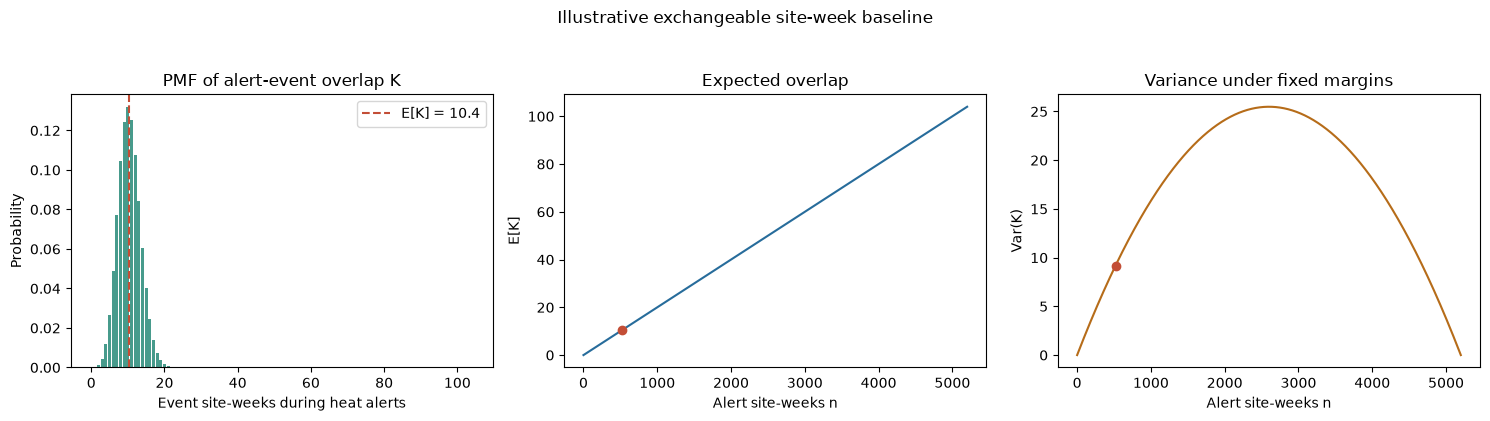

E[K]=10.400; Var(K)=9.175; SD(K)=3.029
PMF sums to 1.000000
Reminder: temporal clustering or seasonality can invalidate uniform allocation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom

population_size = 5200
event_site_weeks = 104
heat_alert_site_weeks = 520
possible_overlaps = np.arange(
    max(0, heat_alert_site_weeks + event_site_weeks - population_size),
    min(heat_alert_site_weeks, event_site_weeks) + 1,
)
overlap_probabilities = hypergeom.pmf(
    possible_overlaps,
    population_size,
    event_site_weeks,
    heat_alert_site_weeks,
)
expected_overlap = hypergeom.mean(
    population_size, event_site_weeks, heat_alert_site_weeks
)
variance_overlap = hypergeom.var(
    population_size, event_site_weeks, heat_alert_site_weeks
)

candidate_sizes = np.arange(population_size + 1)
event_fraction = event_site_weeks / population_size
expected_by_size = candidate_sizes * event_fraction
variance_by_size = (
    candidate_sizes * event_fraction * (1 - event_fraction)
    * (population_size - candidate_sizes) / (population_size - 1)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(possible_overlaps, overlap_probabilities, color="#278a78", alpha=0.85)
axes[0].axvline(expected_overlap, color="#c34e36", linestyle="--", label=f"E[K] = {expected_overlap:.1f}")
axes[0].set(title="PMF of alert-event overlap K", xlabel="Event site-weeks during heat alerts", ylabel="Probability")
axes[0].legend()
axes[1].plot(candidate_sizes, expected_by_size, color="#276c9b")
axes[1].scatter([heat_alert_site_weeks], [expected_overlap], color="#c34e36", zorder=3)
axes[1].set(title="Expected overlap", xlabel="Alert site-weeks n", ylabel="E[K]")
axes[2].plot(candidate_sizes, variance_by_size, color="#b66c19")
axes[2].scatter([heat_alert_site_weeks], [variance_overlap], color="#c34e36", zorder=3)
axes[2].set(title="Variance under fixed margins", xlabel="Alert site-weeks n", ylabel="Var(K)")
fig.suptitle("Illustrative exchangeable site-week baseline", y=1.04)
fig.tight_layout()
plt.show()
print(f"E[K]={expected_overlap:.3f}; Var(K)={variance_overlap:.3f}; SD(K)={np.sqrt(variance_overlap):.3f}")
print(f"PMF sums to {overlap_probabilities.sum():.6f}")
print("Reminder: temporal clustering or seasonality can invalidate uniform allocation.")

### Power demonstration with temporal persistence
For an AR(1)-like correlation $\rho$ among consecutive observations, a rough effective sample-size approximation for a mean is $n_{eff}\approx n(1-\rho)/(1+\rho)$. This is only a teaching approximation, not a replacement for a correctly specified time-series or block-randomization analysis. The simulation compares power for a 3-point increase in weekly event probability when 10% is the baseline, with nominal sample sizes interpreted as independent weeks versus reduced effective counts at $\rho=0.60$. It also checks that the two-sided null rejection rate stays near $\alpha=0.05$ in the simplified binomial benchmark.

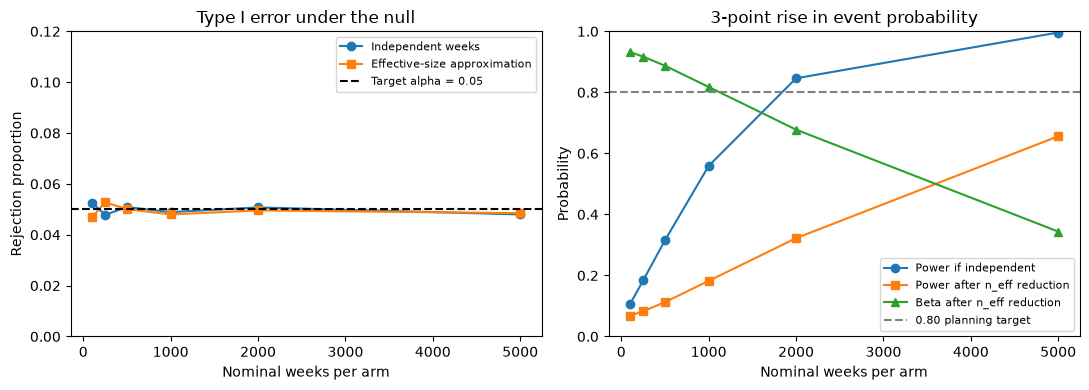

 nominal weeks per arm  n_eff per arm (rho=.60)  alpha, independent  alpha, n_eff approximation  power, independent  power, n_eff approximation  beta, n_eff approximation
                   100                       25               0.053                       0.047               0.106                       0.068                      0.932
                   250                       62               0.048                       0.053               0.184                       0.083                      0.917
                   500                      125               0.051                       0.050               0.315                       0.113                      0.887
                  1000                      250               0.049                       0.048               0.559                       0.182                      0.818
                  2000                      500               0.051                       0.050               0.846                       0.322  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

power_rng = np.random.default_rng(20261008)
nominal_sample_sizes = np.array([100, 250, 500, 1000, 2000, 5000])
replications = 12000
alpha = 0.05
baseline_event_rate = 0.10
elevated_event_rate = 0.13
temporal_correlation = 0.60
effective_sample_sizes = np.maximum(
    2,
    np.rint(
        nominal_sample_sizes
        * (1 - temporal_correlation)
        / (1 + temporal_correlation)
    ).astype(int),
)


def simulate_two_rate_rejection(n_per_arm, treatment_rate):
    control_events = power_rng.binomial(
        n_per_arm[:, None], baseline_event_rate,
        size=(len(n_per_arm), replications),
    )
    treatment_events = power_rng.binomial(
        n_per_arm[:, None], treatment_rate,
        size=(len(n_per_arm), replications),
    )
    pooled_rate = (control_events + treatment_events) / (2 * n_per_arm[:, None])
    standard_error = np.sqrt(
        pooled_rate * (1 - pooled_rate) * 2 / n_per_arm[:, None]
    )
    z_statistic = np.divide(
        treatment_events / n_per_arm[:, None]
        - control_events / n_per_arm[:, None],
        standard_error,
        out=np.zeros_like(pooled_rate, dtype=float),
        where=standard_error > 0,
    )
    return np.abs(z_statistic) > norm.ppf(1 - alpha / 2)


null_rejections_independent = simulate_two_rate_rejection(
    nominal_sample_sizes, baseline_event_rate
)
null_rejections_effective = simulate_two_rate_rejection(
    effective_sample_sizes, baseline_event_rate
)
power_independent = simulate_two_rate_rejection(
    nominal_sample_sizes, elevated_event_rate
).mean(axis=1)
power_effective = simulate_two_rate_rejection(
    effective_sample_sizes, elevated_event_rate
).mean(axis=1)
alpha_independent = null_rejections_independent.mean(axis=1)
alpha_effective = null_rejections_effective.mean(axis=1)
beta_effective = 1 - power_effective

power_table = pd.DataFrame({
    "nominal weeks per arm": nominal_sample_sizes,
    "n_eff per arm (rho=.60)": effective_sample_sizes,
    "alpha, independent": alpha_independent,
    "alpha, n_eff approximation": alpha_effective,
    "power, independent": power_independent,
    "power, n_eff approximation": power_effective,
    "beta, n_eff approximation": beta_effective,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(nominal_sample_sizes, alpha_independent, marker="o", label="Independent weeks")
axes[0].plot(nominal_sample_sizes, alpha_effective, marker="s", label="Effective-size approximation")
axes[0].axhline(alpha, color="black", linestyle="--", label="Target alpha = 0.05")
axes[0].set(title="Type I error under the null", xlabel="Nominal weeks per arm", ylabel="Rejection proportion", ylim=(0, 0.12))
axes[0].legend(fontsize=8)
axes[1].plot(nominal_sample_sizes, power_independent, marker="o", label="Power if independent")
axes[1].plot(nominal_sample_sizes, power_effective, marker="s", label="Power after n_eff reduction")
axes[1].plot(nominal_sample_sizes, beta_effective, marker="^", label="Beta after n_eff reduction")
axes[1].axhline(0.80, color="gray", linestyle="--", label="0.80 planning target")
axes[1].set(title="3-point rise in event probability", xlabel="Nominal weeks per arm", ylabel="Probability", ylim=(0, 1))
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
print(power_table.round(3).to_string(index=False))

### Worked application: compare heat-alert and matched non-alert periods
The rates below are **constructed teaching data**: heat-related emergency visits per 10,000 residents for 12 matched region-season blocks. A paired interval summarizes the mean within-pair difference and makes the comparison unit explicit. In a real study, match or model calendar season and baseline risk, account for serial dependence across blocks, and prespecify the lag and tested regions. Because alert status is not randomized here, the result is an association, not by itself a causal effect.

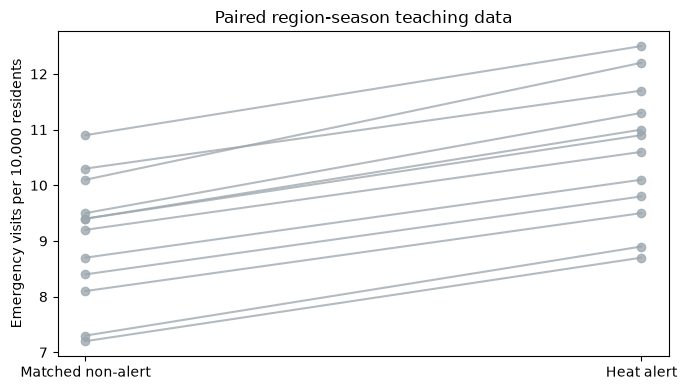

Matched blocks: 12
Mean paired difference (alert - non-alert): 1.56 visits per 10,000
95% paired t interval: [1.42, 1.69]
Two-sided paired t-test: t=25.599, p=0.0000
Interpretation: descriptive association; causal interpretation needs a defensible design and dependence-aware analysis.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_1samp

alert_rate_per_10k = np.array([8.7, 10.1, 11.0, 9.5, 12.2, 8.9, 10.6, 11.7, 9.8, 12.5, 10.9, 11.3])
matched_no_alert_rate_per_10k = np.array([7.2, 8.7, 9.4, 8.1, 10.1, 7.3, 9.2, 10.3, 8.4, 10.9, 9.4, 9.5])
paired_differences = alert_rate_per_10k - matched_no_alert_rate_per_10k
number_of_pairs = len(paired_differences)
mean_difference = paired_differences.mean()
standard_error = paired_differences.std(ddof=1) / np.sqrt(number_of_pairs)
critical_t = t.ppf(0.975, df=number_of_pairs - 1)
confidence_interval = (
    mean_difference - critical_t * standard_error,
    mean_difference + critical_t * standard_error,
)
t_statistic, p_value = ttest_1samp(paired_differences, popmean=0)

fig, ax = plt.subplots(figsize=(7, 4))
block_positions = np.arange(1, number_of_pairs + 1)
for index in block_positions:
    ax.plot(
        [0, 1],
        [matched_no_alert_rate_per_10k[index - 1], alert_rate_per_10k[index - 1]],
        color="#9aa5ad",
        alpha=0.75,
        marker="o",
    )
ax.set_xticks([0, 1], ["Matched non-alert", "Heat alert"])
ax.set_ylabel("Emergency visits per 10,000 residents")
ax.set_title("Paired region-season teaching data")
fig.tight_layout()
plt.show()

print(f"Matched blocks: {number_of_pairs}")
print(f"Mean paired difference (alert - non-alert): {mean_difference:.2f} visits per 10,000")
print(f"95% paired t interval: [{confidence_interval[0]:.2f}, {confidence_interval[1]:.2f}]")
print(f"Two-sided paired t-test: t={t_statistic:.3f}, p={p_value:.4f}")
print("Interpretation: descriptive association; causal interpretation needs a defensible design and dependence-aware analysis.")

## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

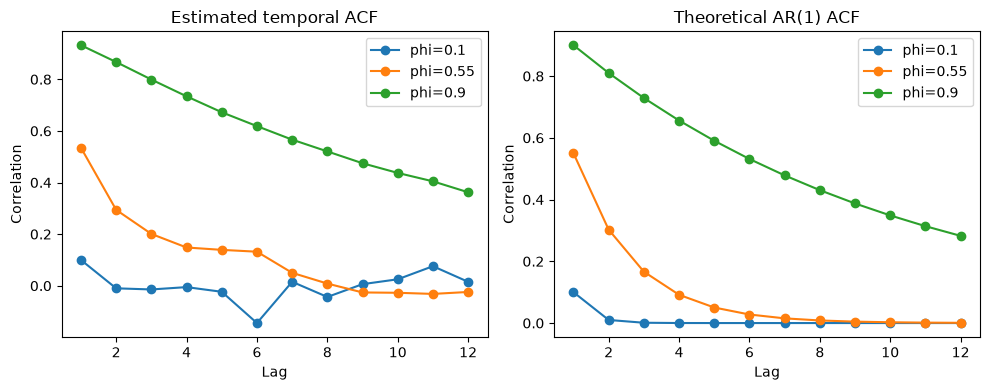

In [4]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(19);T=500
fig,axs=plt.subplots(1,2,figsize=(10,4))
for phi in [.1,.55,.9]:
 x=np.zeros(T);noise=rng.normal(size=T)
 for t in range(1,T):x[t]=phi*x[t-1]+noise[t]
 x=x[100:]; ac=[np.corrcoef(x[h:],x[:-h])[0,1] for h in range(1,13)]
 axs[0].plot(range(1,13),ac,marker='o',label=f'phi={phi}')
 axs[1].plot(range(1,13),[phi**h for h in range(1,13)],marker='o',label=f'phi={phi}')
axs[0].set(title='Estimated temporal ACF',xlabel='Lag',ylabel='Correlation')
axs[1].set(title='Theoretical AR(1) ACF',xlabel='Lag',ylabel='Correlation')
for a in axs:a.legend()
plt.tight_layout();plt.show()

```mermaid
flowchart LR
    A[Generate environmental time series] --> B[Align X at t−lag]
    B --> C[Keep common target periods]
    C --> D[Simulate Y at focal t]
    D --> E[Compare lift by lag]
    E --> F[Interpret lag uncertainty]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $X_{s,t-\ell}$ | environmental predicate at location $s$ and earlier period |
| $Y_{s,t}$ | target outcome at focal period |
| $\ell$ | specified temporal lag（时间滞后） |
| $\rho$ | persistence parameter in binary process |
| $\beta$ | planted event-effect coefficient |

$$L_\ell=\frac{P(Y_t=1\mid X_{t-\ell}=1)}{P(Y_t=1)}.$$

One illustrative two-state process uses stationary probability $p$ and transitions $P(X_t=1\mid X_{t-1}=x)=\rho x+(1-\rho)p$, where $0\le\rho<1$. Its lag-$h$ correlation is $\rho^h$ in stationarity.

---

## Core Mechanisms and Concepts

### Temporal alignment

The target is observed at $t$ and context at $t-\ell$. Keep the same focal-period population across lags; otherwise the background target prevalence and observation composition change.

### Persistence and lag leakage

If $X_t$ persists, an effect planted at $t-2$ can induce real marginal association at $t-1$ or $t-3$. A detected lag is not automatically the physical or causal delay.

### Seasonal baseline

An event probability that changes by month can be correlated with seasonal environmental conditions even without a direct mechanism. Stratifying randomizations by calendar month is a possible reference restriction, but it is only inferentially valid under the correct within-stratum exchangeability conditions.

### Anchors reused across time

The same spatial support at many focal periods creates clustered observations. A point-process or trajectory-aware reference may preserve aspects of this structure; arbitrary row shuffling generally does not.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume environmental states have a stated transition law and that target outcomes are generated with a prespecified lag in the toy experiment. Strength: known planted temporal structure. Limitation: a stationary first-order Markov process is not a full wildfire climate model.

**Trade-off:** stronger persistence improves continuity of environment but makes adjacent lag associations harder to distinguish.

## Worked Toy Example

If an event probability is increased when $X_{t-2}=1$, a persistent binary climate field produces correlation between $X_{t-2}$ and $X_{t-1}$. Therefore both $L_2$ and $L_1$ may exceed one, although only lag 2 appears in the generating event equation.

## Python Lab: Set Up the Dataset

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Generate Markov environmental fields

Use many sites and focal periods to visualize temporal persistence.

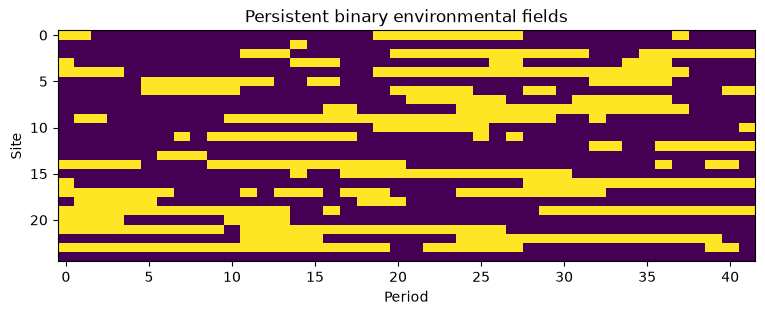

In [6]:
def markov_field(n_sites,T,p=.35,rho=.75,rng=None):
 rng=np.random.default_rng(0) if rng is None else rng
 x=np.zeros((n_sites,T),dtype=int);x[:,0]=rng.binomial(1,p,n_sites)
 for t in range(1,T):
  prob=rho*x[:,t-1]+(1-rho)*p
  x[:,t]=rng.binomial(1,prob)
 return x
X=markov_field(150,42,rho=.75,rng=rng)
fig,ax=plt.subplots(figsize=(9,3));ax.imshow(X[:25],aspect='auto',interpolation='nearest');ax.set(xlabel='Period',ylabel='Site',title='Persistent binary environmental fields');plt.show()

**Interpretation.** At high persistence the binary states form longer temporal runs; adjacent lag predictors are correlated.

## Plant a lag-2 mechanism

Generate Y from lag-2 X without calling the result causal inference.

In [7]:
focal=np.arange(5,42);base_p=.07;beta=1.1
prob=1-np.exp(np.log(1-base_p)*np.exp(beta*X[:,focal-2]))
Y=rng.binomial(1,prob)
print('Target prevalence:',Y.mean(),'focal periods:',len(focal))

Target prevalence: 0.10882882882882883 focal periods: 37


**Interpretation.** The data-generation equation defines a planted delay, but inference from observed rules only characterizes lagged association.

## Plot the lag profile

Use identical target observations for every lag.

   lag     n    K   lift
0    0  1800  277  1.414
1    1  1800  304  1.552
2    2  1796  340  1.740
3    3  1794  308  1.578
4    4  1797  289  1.478
5    5  1802  268  1.367


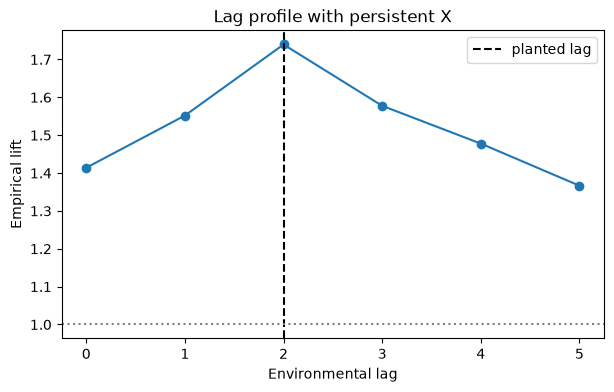

In [8]:
def lag_lifts(X,Y,focal,lags):
 out=[]
 for lag in lags:
  z=X[:,focal-lag].reshape(-1);y=Y.reshape(-1);n=z.sum();m=y.sum();N=len(y);K=np.dot(z,y)
  out.append({'lag':lag,'n':n,'K':K,'lift':K*N/(n*m)})
 return pd.DataFrame(out)
profile=lag_lifts(X,Y,focal,range(6))
print(profile.round(3))
fig,ax=plt.subplots(figsize=(7,4));ax.plot(profile.lag,profile.lift,marker='o');ax.axvline(2,linestyle='--',color='black',label='planted lag');ax.axhline(1,linestyle=':',color='gray');ax.set(xlabel='Environmental lag',ylabel='Empirical lift',title='Lag profile with persistent X');ax.legend();plt.show()

**Interpretation.** A pronounced peak at lag 2 is useful descriptive evidence, but adjacent lags may have genuine noncausal marginal associations.

## Sensitivity to persistence

Repeat independent simulations and average lag-specific lift profiles.

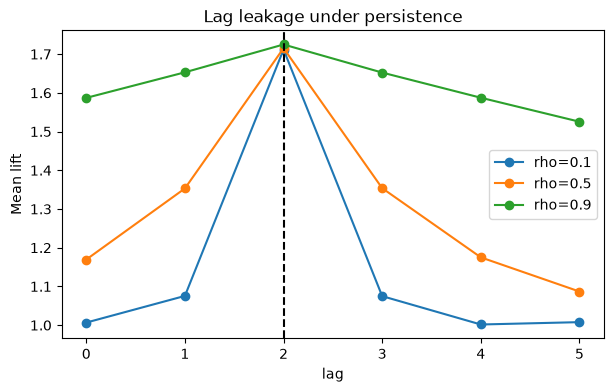

In [9]:
result=[]
for rho in [0.1,0.5,0.9]:
 for rep in range(120):
  xx=markov_field(120,42,rho=rho,rng=rng)
  pp=1-np.exp(np.log(1-base_p)*np.exp(beta*xx[:,focal-2]))
  yy=rng.binomial(1,pp)
  tmp=lag_lifts(xx,yy,focal,range(6));tmp['rho']=rho;tmp['rep']=rep;result.append(tmp)
ans=pd.concat(result).groupby(['rho','lag'],as_index=False).lift.mean()
fig,ax=plt.subplots(figsize=(7,4))
for rho,g in ans.groupby('rho'):ax.plot(g.lag,g.lift,marker='o',label=f'rho={rho}')
ax.axvline(2,linestyle='--',color='black');ax.set(xlabel='lag',ylabel='Mean lift',title='Lag leakage under persistence');ax.legend();plt.show()

**Interpretation.** Lag persistence broadens the lift profile around the planted mechanism; a lagged rule is not a uniquely identified causal delay.

---

## Common Pitfalls and Misunderstandings

- Different eligible anchors across lags make lift comparisons ambiguous.
- Temporal ordering by itself does not establish causality.
- A lagged association can be induced by serial dependence and shared seasonality.
- Repeated location-months are not independent observations by default.
- Annual vegetation observed after a focal event should be called context, not necessarily a precursor.

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: What makes an AR(1) model weakly stationary in the usual setup?

A. phi>1  
B. abs(phi)<1 with stable innovation variance  
C. No random noise  
D. A finite series length

<details>
<summary>Answer</summary>

**B. In the usual AR(1) model, |phi|<1 gives finite stationary variance.**

</details>

---

### Q2: Can an association at lag 1 be real when the generating mechanism acts only at lag 2?

A. Never  
B. Yes, through temporal persistence  
C. Only if simulation is wrong  
D. Only with spatial overlap

<details>
<summary>Answer</summary>

**B. Correlated antecedent history can create genuine marginal associations at nearby lags.**

</details>

---

### Q3: Why is seasonal shuffling not automatically valid?

A. It always loses too much data  
B. It requires within-stratum exchangeability  
C. It is only for daily series  
D. It is equivalent to CSR

<details>
<summary>Answer</summary>

**B. Conditioning on month does not by itself justify arbitrary label allocation within that month.**

</details>

---

### Q4: What is the danger of using an annual measurement collected after an event?

A. Increased variance only  
B. Look-ahead leakage and misleading temporal interpretation  
C. It ensures stationarity  
D. None

<details>
<summary>Answer</summary>

**B. Future information cannot be treated as an antecedent exposure.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.